### 0. Requirements

run once

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn torch torchvision torchaudio transformers datasets accelerate tqdm nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.5 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 10.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import os
import string
import re
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    AutoTokenizer, 
    AutoModelForSequenceClassification
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensuring required NLTK components are available
nltk.download('punkt')
nltk.download('stopwords')

c:\Users\PC MOD NEPAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to C:\Users\PC MOD
[nltk_data]     NEPAL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\PC MOD
[nltk_data]     NEPAL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\PC MOD
[nltk_data]     NEPAL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [4]:
def get_device_and_config():
    config = {}

    # CUDA GPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
        backend = "CUDA GPU"

        config.update({
            "per_device_train_batch_size": 32,
            "per_device_eval_batch_size": 32,
            "fp16": True,
            "gradient_accumulation_steps": 1
        })

    # Apple Silicon (MPS)
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        backend = "Apple Silicon (MPS)"

        config.update({
            "per_device_train_batch_size": 16,
            "per_device_eval_batch_size": 16,
            "fp16": False,   # unstable on MPS
            "gradient_accumulation_steps": 1
        })

    # TPU (XLA)
    elif "COLAB_TPU_ADDR" in os.environ:
        import torch_xla.core.xla_model as xm
        device = xm.xla_device()
        backend = "TPU"

        config.update({
            "per_device_train_batch_size": 32,
            "per_device_eval_batch_size": 32,
            "fp16": False,
            "gradient_accumulation_steps": 2
        })

    # CPU fallback
    else:
        device = torch.device("cpu")
        backend = "CPU"

        config.update({
            "per_device_train_batch_size": 8,
            "per_device_eval_batch_size": 8,
            "fp16": False,
            "gradient_accumulation_steps": 2
        })

    return device, backend, config


device, backend, perf_config = get_device_and_config()
print(f"Device detected: {backend}")
print("Auto performance config:", perf_config)

Device detected: CUDA GPU
Auto performance config: {'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 32, 'fp16': True, 'gradient_accumulation_steps': 1}


### 2. Read the dataset

In [5]:
df = pd.read_csv("combined_ai_human.csv")

df.head()


,text,generated
0,# The Human Toll of Nuclear Testing: A Legacy ...,1
1,"**Title: In the Age of Coronavirus, the Only W...",1
2,"**Roberta Karmel, First Woman Named to the S.E...",1
3,"**Summer Reading Contest, Week 2: What Got You...",1
4,**Title: The Spectacle Returns: A Record-Break...,1


In [6]:
print(df.info())
print(df['generated'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44552 entries, 0 to 44551
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       44552 non-null  object
 1   generated  44552 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 696.3+ KB
None
generated
0    22820
1    21732
Name: count, dtype: int64


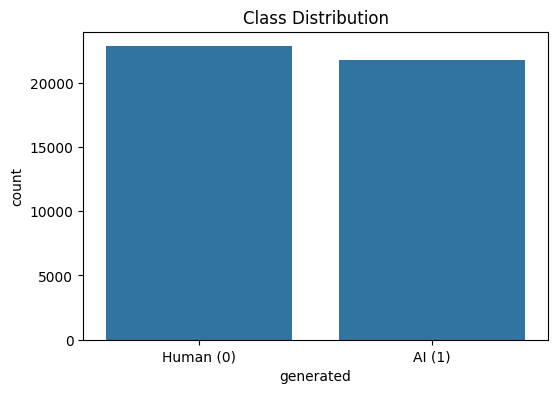

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='generated', data=df)
plt.xticks([0,1], ['Human (0)', 'AI (1)'])
plt.title("Class Distribution")
plt.show()


### 3. Text length Analysis

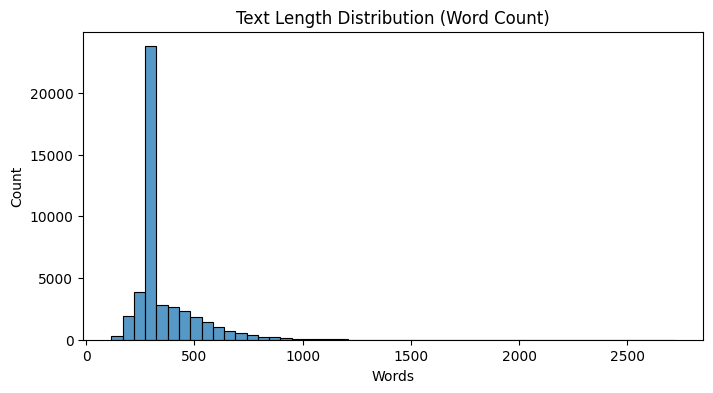

In [8]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution (Word Count)")
plt.xlabel("Words")
plt.show()


### Cleaning text

In [9]:
def clean_text(text):
    """
    Cleans the input text by performing several operations:
    - Convert to lowercase to maintain uniformity.
    - Remove punctuation to reduce noise.
    - Remove numbers as they may not contribute to text classification in this context.
    - Strip extra spaces for clean, standardized input.
    - Remove stopwords to focus on the meaningful words.
    
    Parameters:
    text (str): The input text to be cleaned.
    
    Returns:
    str: The cleaned text.
    """
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = text.strip()
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    text = ' '.join(filtered_tokens)
    return text

In [10]:
# Cleaning the text column in the downsized dataframe
df['text'] = df['text'].apply(clean_text)
df['text'] = df['text'].fillna("")  # Replacing NaN with empty strings

In [11]:
df

,text,generated,text_length
0,human toll nuclear testing legacy suffering re...,1,300
1,title age coronavirus way see milan fly name m...,1,300
2,roberta karmel first woman named sec dies name...,1,300
3,summer reading contest week got attention time...,1,300
4,title spectacle returns recordbreaking debut z...,1,300
...,...,...,...
44547,uncommon students choose enjoy summer free lea...,0,745
44548,projects another way fun learning something ne...,0,393
44549,school year students continually asked complet...,0,411
44550,students education ongoing process easily disr...,0,552


### 4. Train and Validation splitting

In [12]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['generated'],
    test_size=0.2, # 80 to 20 split
    stratify=df['generated'], # keeps the proportion same
    random_state=42
)


### 5. Loading BERT tokenizer

In [13]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")


### 6. Tokenize the text column

In [14]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True, # cuts long texts
    padding=True, # equal sequence length
    max_length=300 # max length is 300 as previously done in preprocessing
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=300
)


### 7. Custom pytorch dataset
This wraps tokenized data into a format Hugging Face Trainer understands.

In [16]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


### 8. Create Dataset Objects
Creates training and validation datasets for the model.

In [17]:
train_dataset = TextDataset(train_encodings, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)


### 9. Load BERT model


In [18]:
# model = BertForSequenceClassification.from_pretrained(
#     "bert-base-uncased",
#     num_labels=2 # Human vs AI
# )

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)


c:\Users\PC MOD NEPAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PC MOD NEPAL\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1131.11it/s, Materializing 

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### 10. Training Arguments

In [19]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="none",

    # Auto-detected performance settings
    per_device_train_batch_size=perf_config["per_device_train_batch_size"],
    per_device_eval_batch_size=perf_config["per_device_eval_batch_size"],
    fp16=perf_config["fp16"],
    gradient_accumulation_steps=perf_config["gradient_accumulation_steps"],
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [20]:
# training_args = TrainingArguments(
#     output_dir="./results",
#     evaluation_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5, # Standard BERT learning rate is 2e-5
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     load_best_model_at_end=True, # tries to avoid overfitting
#     metric_for_best_model="eval_loss"
# )

# training_args = TrainingArguments(
#     output_dir="./results",
#     evaluation_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5, # Standard BERT learning rate is 2e-5
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     logging_steps=100,
#     load_best_model_at_end=True, # tries to avoid overfitting
#     metric_for_best_model="f1",
#     report_to="none"
# )

In [21]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### 11. Define trainer
Hugging Face Trainer handles: training loop, evaluation and checkpointing

In [22]:
# Shows precision, recall, F1-score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


### 12. Train the model

In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.004004,0.007567,0.998541,0.997246,0.999770,0.998507
2,0.000033,0.002228,0.999551,0.999310,0.999770,0.999540
3,0.000017,0.002950,0.999551,0.999310,0.999770,0.999540


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.33it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=3342, training_loss=0.004031199257974672, metrics={'train_runtime': 968.3407, 'train_samples_per_second': 110.419, 'train_steps_per_second': 3.451, 'total_flos': 1.653822566235e+16, 'train_loss': 0.004031199257974672, 'epoch': 3.0})

### 13. Evaluation

In [26]:
preds = trainer.predict(val_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(val_labels, y_pred)) 

# Converts logits → class predictions

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4564
           1       1.00      1.00      1.00      4347

    accuracy                           1.00      8911
   macro avg       1.00      1.00      1.00      8911
weighted avg       1.00      1.00      1.00      8911



In [27]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.0022357909474521875, 'eval_accuracy': 0.9995511165974638, 'eval_precision': 0.9993101862497126, 'eval_recall': 0.9997699562916954, 'eval_f1': 0.999540018399264, 'eval_runtime': 21.1602, 'eval_samples_per_second': 421.121, 'eval_steps_per_second': 13.185, 'epoch': 3.0}


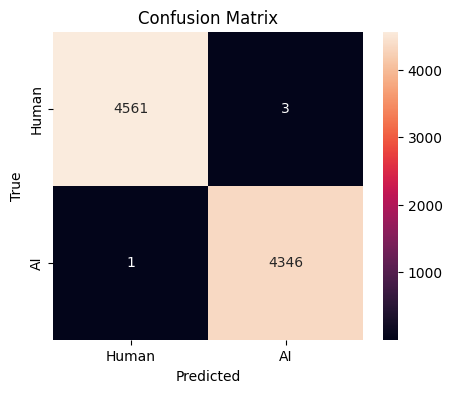

In [28]:
cm = confusion_matrix(val_labels, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Human", "AI"],
            yticklabels=["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### 14. Saving the model


In [29]:
trainer.save_model("./bert_ai_human_detector")
tokenizer.save_pretrained("./bert_ai_human_detector")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.73it/s]


('./bert_ai_human_detector\\tokenizer_config.json',
 './bert_ai_human_detector\\tokenizer.json')